In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive"

 Ag		    datass		       'Untitled spreadsheet.gsheet'
 a.gscript	    labMate		        Wildlife.v1i.yolo26.zip
'Colab Notebooks'  'Untitled project.gscript'


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/Wildlife.v1i.yolo26.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Done!")

Done!


In [4]:
!find /content/dataset -name "data.yaml"

/content/dataset/data.yaml


In [5]:
!find /content/dataset | head -30

/content/dataset
/content/dataset/valid
/content/dataset/valid/labels
/content/dataset/valid/labels/af_tr56_jpg.rf.1327190bb4c4ba68415a102fa0ee6260.txt
/content/dataset/valid/labels/Image_112_jpg.rf.6f6d0f96b4bf2b01095cdfdc51d9a503.txt
/content/dataset/valid/labels/as_tr103_jpg.rf.fdc016da4b6ac9ec45be87904b762147.txt
/content/dataset/valid/labels/5QIDPT7O815P_jpg.rf.7eb5234928607da18be15edb72ccba4f.txt
/content/dataset/valid/labels/COCO_train2014_000000577221_jpg.rf.6cbde9b2e35f3cdc50bec9f4f00b97af.txt
/content/dataset/valid/labels/as_tr112_jpg.rf.2ceef88dca8c5613f0fa123ae6d50721.txt
/content/dataset/valid/labels/as_tr191_jpg.rf.d12036b6d6dedf8a2c08dee2d741b682.txt
/content/dataset/valid/labels/BOAR3_jpg.rf.db86a68e86d8bd763118d7cf07bfc1f9.txt
/content/dataset/valid/labels/COCO_train2014_000000579051_jpg.rf.8f30e413c008c562ef36f7db04844240.txt
/content/dataset/valid/labels/b7887ed1-280f-419e-a085-e3a9632c8949_jpg.rf.419e6a80b456a9d6b82e19db2e2e6a92.txt
/content/dataset/valid/labels/COC

In [7]:
!apt-get -qq install tree
!tree -L 3 /content/dataset

Selecting previously unselected package tree.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
/content/dataset
├── data.yaml
├── README.dataset.txt
├── README.roboflow.txt
├── test
│   ├── images
│   │   ├── 00016_jpg.rf.c286f8ad81441784c618741f6a6509cd.jpg
│   │   ├── 013_jpg.rf.23c6c950f7e1fcca3d4ad190f33f2f88.jpg
│   │   ├── 050_jpg.rf.5b272308d87020f79cb4c64e91ae841e.jpg
│   │   ├── 08438f01-8e54-4bd5-acdd-2782e38ee45f_jpg.rf.4c48314ecc0c5b6e484e6ab62892fde9.jpg
│   │   ├── 094_jpg.rf.72cac405f084e68e7cadafd2ac82884d.jpg
│   │   ├── 0S1OLAE4B4RT_jpg.rf.a3dd5a1a8604948690895bd237e113c9.jpg
│   │   ├── 0US2FO51B59E_jpg.rf.fa243d36f0f5102ab6bb909c35724341.jpg
│   │   ├── -106-_jpg.rf.a312aef98e7decb439102cae8ced105a.jpg
│   │   ├── 11e232022401e363_jpg.rf.3c959d5d8b56d55412b9f517f3d75f8d.jpg
│   │   ├── 12b

In [8]:
with open("/content/dataset/data.yaml", "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['Bear', 'Boar', 'Elephant']

roboflow:
  workspace: srimathy
  project: wildlife-gsee1-zn1nu
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/srimathy/wildlife-gsee1-zn1nu/dataset/1


In [9]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00


In [10]:
%%writefile /content/dataset/data.yaml

train: /content/dataset/train/images
val: /content/dataset/valid/images
test: /content/dataset/test/images

nc: 3

names:
  0: Bear
  1: Boar
  2: Elephant

Overwriting /content/dataset/data.yaml


In [13]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2
)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

In [14]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 686.6±337.1 MB/s, size: 450.2 KB)
val: Scanning /content/dataset/valid/labels.cache... 271 images, 76 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 271/271 63.1Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 301, len(boxes) = 333. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.0it/s 8.5s
                   all        271        333      0.953      0.786      0.882      0.764
                  Bear         57         63      0.965      0.872      0.946      0.859
                  Boar         72       

In [17]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

results = model.predict(
    source="/content/dataset/test/images/00016_jpg.rf.c286f8ad81441784c618741f6a6509cd.jpg", # Changed to an existing test image
    conf=0.25,
    save=True
)

print(results)


image 1/1 /content/dataset/test/images/00016_jpg.rf.c286f8ad81441784c618741f6a6509cd.jpg: 640x640 1 Boar, 13.7ms
Speed: 3.2ms preprocess, 13.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Bear', 1: 'Boar', 2: 'Elephant'}
obb: None
orig_img: array([[[49, 55, 60],
        [49, 55, 60],
        [49, 55, 60],
        ...,
        [ 7, 55, 57],
        [ 6, 54, 56],
        [ 6, 54, 56]],

       [[49, 55, 60],
        [49, 55, 60],
        [49, 55, 60],
        ...,
        [ 7, 55, 57],
        [ 6, 54, 56],
        [ 6, 54, 56]],

       [[49, 55, 60],
        [49, 55, 60],
        [49, 55, 60],
        ...,
        [ 7, 55, 57],
        [ 7, 55, 57],
        [ 6, 54, 56]],

       ...,

       [[75, 71, 82],
        [75, 74, 84],
        [81, 77, 88],
        ...,
        [

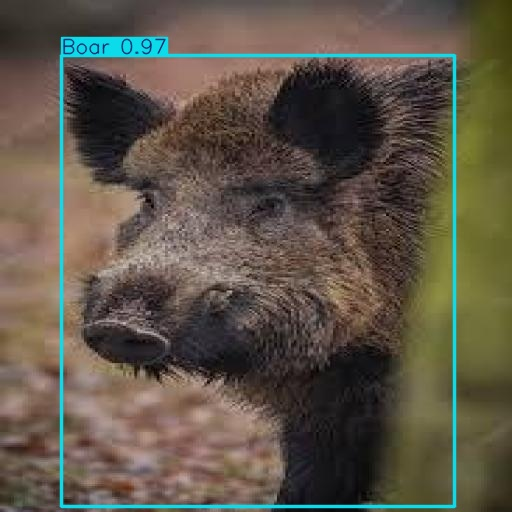

In [19]:
from IPython.display import Image

# The output image is saved in the 'predict' directory within runs/detect
# The filename will be the same as the input image.
output_image_path = '/content/runs/detect/predict/00016_jpg.rf.c286f8ad81441784c618741f6a6509cd.jpg'

display(Image(filename=output_image_path, width=600))

In [20]:
model.export(format="onnx")

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 316ms
Prepared 4 packages in 1.88s
Installed 4 packages in 277ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.0s, saved as 'runs/detect/train/weights/best.onnx' (9.4 MB)

Export complete (5.3s)
Results saved to /content/runs/detect/train/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=640 data=/content/dataset/data.yaml  
Visualize:       https://netron.app


'runs/detect/train/weights/best.onnx'

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
!cp /content/runs/detect/train/weights/best.pt \
    /content/drive/MyDrive/best.pt

In [23]:
!cp /content/runs/detect/train/weights/best.onnx \
    /content/drive/MyDrive/best.onnx

In [24]:
!ls -lh runs/detect/train/weights/

total 20M
-rw-r--r-- 1 root root 9.4M Jun 17 04:35 best.onnx
-rw-r--r-- 1 root root 5.2M Jun 17 04:31 best.pt
-rw-r--r-- 1 root root 5.2M Jun 17 04:31 last.pt
